# Factor modeling

In [74]:
from numpy.random import normal
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# single factor model

$U_i = a_i * F + \sqrt{1 - a_i^2} * Z_i$

where $F$ is the common factor and $Z_i$ is the unique non-systemic random variable for each investment

In [97]:
a = np.array([[.8,.3,-.9,.5]])   # exposure of the investments to the single factor
n_factors = len(a)
n_investments = len(a.T)
n = 10000

print(f"number of factors (M) = {n_factors}, number of investments = {n_investments}")
print(f"one factor weights {a[0]}\n")
F = np.array(normal(size=(n, n_factors)))  # generate expoosures to the factors
Z = np.array(normal(size=(n, n_investments)))  # generate the idiosyncratic returns for the investments

sqrt1_a2 = np.diag([np.sqrt(1-x) for x in sum(a * a)])
print("idiosyncratuc random returns for each investment:")
print(sqrt1_a2)
print()
U = F.dot(a) + Z.dot(sqrt1_a2)
print(np.round(U,3))

number of factors (M) = 1, number of investments = 4
one factor weights [ 0.8  0.3 -0.9  0.5]

idiosyncratuc random returns for each investment:
[[0.6        0.         0.         0.        ]
 [0.         0.9539392  0.         0.        ]
 [0.         0.         0.43588989 0.        ]
 [0.         0.         0.         0.8660254 ]]

[[ 2.07   1.126 -1.355  0.615]
 [-2.212 -2.265  1.851 -0.505]
 [-1.748  0.463 -0.246 -0.269]
 ...
 [-0.371  0.275 -0.249  1.295]
 [-0.69  -0.784  0.889 -0.196]
 [ 0.883  1.727 -1.273  0.43 ]]


In [76]:
Z.dot(sqrt1_a2)

array([[ 0.24754367, -0.49662107, -0.17087036,  0.82975919],
       [-0.14960548, -1.2001478 , -0.46976612, -0.44169657],
       [ 0.3298455 , -0.81654681, -0.2437791 , -0.17637685],
       ...,
       [-1.51574859, -0.56628353, -0.13520874, -1.05601042],
       [ 0.34519445, -0.39008455,  0.53405199, -0.28074682],
       [ 0.16586697, -0.31551006, -0.20146203,  0.25159351]],
      shape=(10000, 4))

factor weights: [ 0.8  0.3 -0.9  0.5]


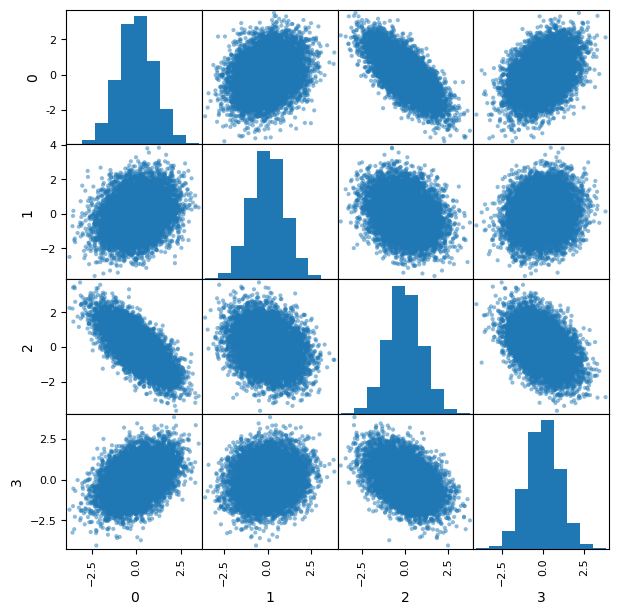

In [94]:
print(f"factor weights: {a[0]}")
pd.plotting.scatter_matrix(pd.DataFrame(U), figsize=(7,7))
plt.show()

In [83]:
print("correlation matrix of the randomly generated series")
corr_mat = np.corrcoef(U.T)
print(corr_mat)

correlation matrix of the randomly generated series
[[ 1.          0.24364954 -0.71954327  0.39158339]
 [ 0.24364954  1.         -0.26122013  0.13659891]
 [-0.71954327 -0.26122013  1.         -0.44078514]
 [ 0.39158339  0.13659891 -0.44078514  1.        ]]


# correlation matrix

$corr(U_i, U_j) = a_i * a_j$

In [79]:
corr_mat_a = np.outer(a, a)
np.fill_diagonal(corr_mat_a, 1)

print("correlation matrix from the a's in the model specification")
corr_mat_a

correlation matrix from the a's in the model specification


array([[ 1.  ,  0.24, -0.72,  0.4 ],
       [ 0.24,  1.  , -0.27,  0.15],
       [-0.72, -0.27,  1.  , -0.45],
       [ 0.4 ,  0.15, -0.45,  1.  ]])

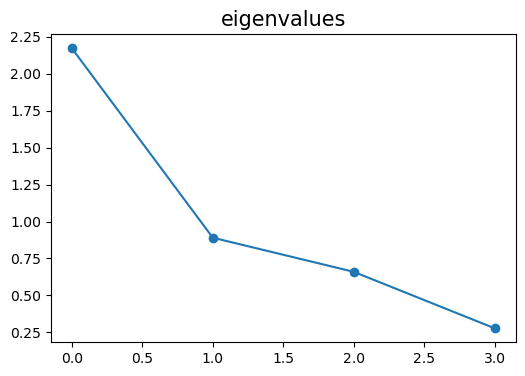

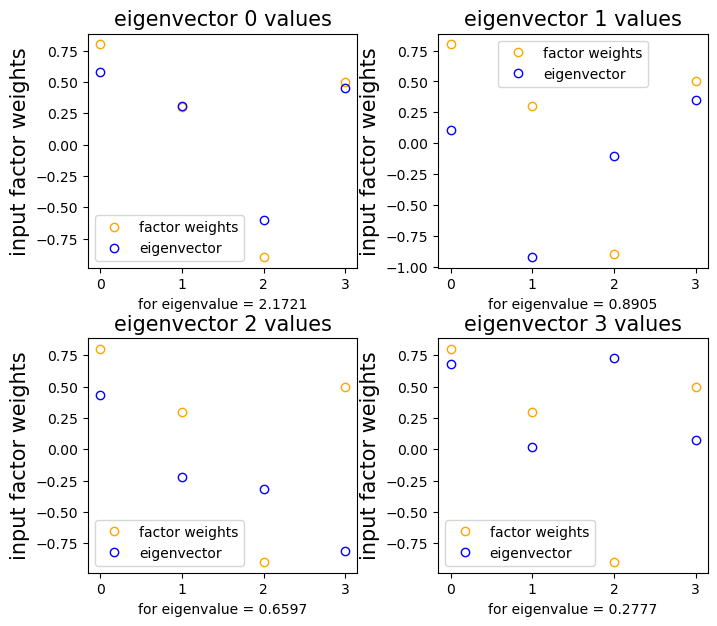

In [95]:
A = np.array(corr_mat, dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(A)

ranked_evals = sorted(enumerate(eigenvalues), key=lambda x: x[1], reverse=True)
ranks = [i for i,_ in ranked_evals]

plt.figure(figsize=(6, 4))
plt.plot([eval for i,eval in ranked_evals], 'o-')
plt.title("eigenvalues", fontsize=15)
plt.show()

print()
fig, axs = plt.subplots(2, 2, figsize=(8, 7))
plt.subplots_adjust(wspace=.3, hspace=.3)

ii,jj = 0,0
for i, (eval_rank, eval) in enumerate(ranked_evals):
    axs[ii,jj].plot(a[0], 'o', markerfacecolor='none', color="orange", label=f"factor weights")
    axs[ii,jj].plot(eigenvectors.T[eval_rank], 'o', markerfacecolor='none', color="blue", label="eigenvector")
    axs[ii,jj].set_ylabel("input factor weights", fontsize=15)
    axs[ii,jj].set_xlabel(f"for eigenvalue = {eval:0.4f}")
    axs[ii,jj].set_title(f"eigenvector {i} values", fontsize=15)
    axs[ii,jj].legend()
    jj += 1
    if jj == 2:
        jj = 0
        ii += 1
plt.show()

In [81]:
# Perform Cholesky decomposition
cholesky_matrix = np.linalg.cholesky(corr_mat)

# Display the Cholesky matrix
print("Cholesky decomposition:")
print(cholesky_matrix)

Cholesky decomposition:
[[ 1.          0.          0.          0.        ]
 [ 0.24364954  0.96986334  0.          0.        ]
 [-0.71954327 -0.08857304  0.68877594  0.        ]
 [ 0.39158339  0.04246969 -0.22541768  0.89109239]]
